In [17]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [32]:
df = pd.read_csv("stock_data_50_records.csv")


In [33]:
df

,Date,Open,High,Low,Close,Volume
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0
5,2026-01-09,104.91,108.22,103.42,107.07,81919.0
6,2026-01-12,107.95,109.49,104.84,106.57,45600.0
7,2026-01-13,109.53,111.44,107.88,NaN,69124.0
8,2026-01-14,108.89,111.08,107.60,109.85,67643.0
9,2026-01-15,110.07,114.76,109.21,112.32,80764.0


In [19]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes


Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
dtype: object

In [20]:
df.shape

(50, 6)

In [21]:
df.isnull().sum()

Date      0
Open      1
High      1
Low       0
Close     1
Volume    1
dtype: int64

In [38]:
df["Close"] = df["Close"].ffill()
df["Open"] = df["Open"].bfill()
df["Volume"] = df["Volume"].ffill()
df["High"] = df["High"].ffill()
df

,Date,Open,High,Low,Close,Volume
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0
5,2026-01-09,104.91,108.22,103.42,107.07,81919.0
20,2026-01-09,104.91,108.22,103.42,107.07,81919.0
6,2026-01-12,107.95,109.49,104.84,106.57,45600.0
7,2026-01-13,109.53,111.44,107.88,106.57,69124.0
8,2026-01-14,108.89,111.08,107.60,109.85,67643.0


In [24]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [25]:
df.duplicated().sum()


np.int64(3)

In [34]:
df = df.sort_values("Date")

In [27]:
df["MA_5"] = df["Close"].rolling(5).mean()
df["MA_20"] = df["Close"].rolling(20).mean()
df


,Date,Open,High,Low,Close,Volume,MA_5,MA_20
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0,NaN,NaN
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0,NaN,NaN
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0,NaN,NaN
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0,NaN,NaN
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0,103.668,NaN
5,2026-01-09,104.91,108.22,103.42,107.07,81919.0,104.674,NaN
20,2026-01-09,104.91,108.22,103.42,107.07,81919.0,105.972,NaN
6,2026-01-12,107.95,109.49,104.84,106.57,45600.0,107.014,NaN
7,2026-01-13,109.53,111.44,107.88,106.57,69124.0,106.954,NaN
8,2026-01-14,108.89,111.08,107.60,109.85,67643.0,107.426,NaN


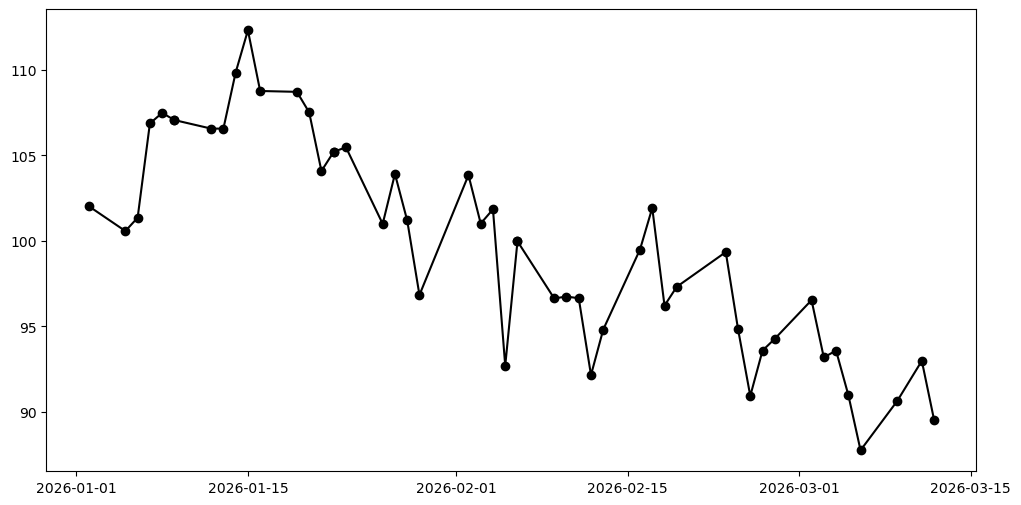

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["Date"],
    df["Close"],
    label="Actual Close Price",
    color="black",
    marker="o"
)


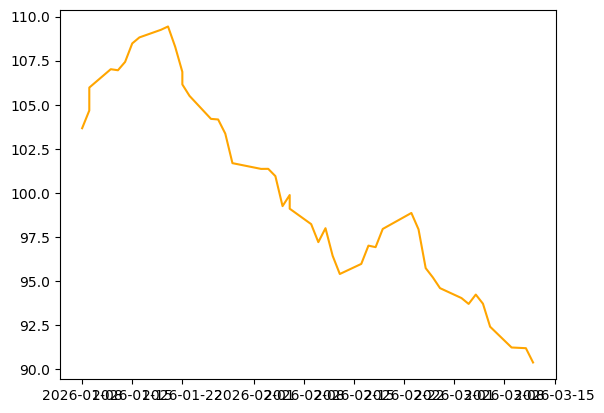

In [31]:
plt.plot(
    df["Date"],
    df["MA_5"],
    label="5-Day Moving Average",
    color="orange"
)


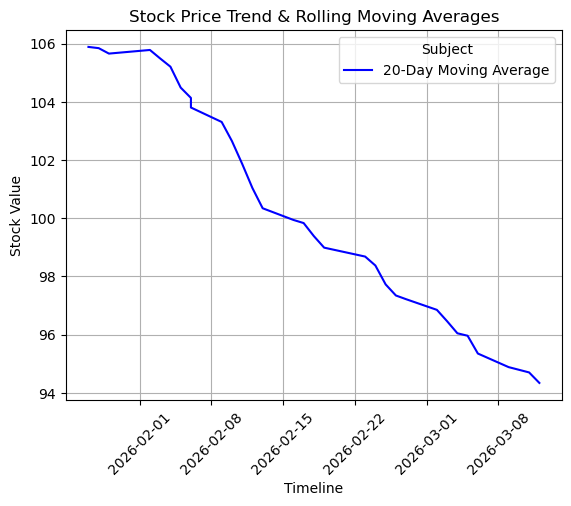

In [30]:
plt.plot(
    df["Date"],
    df["MA_20"],
    label="20-Day Moving Average",
    color="blue"
)

plt.title("Stock Price Trend & Rolling Moving Averages")
plt.xlabel("Timeline")
plt.ylabel("Stock Value")
plt.grid(True)
plt.legend(title="Subject")
plt.xticks(rotation=45)
plt.show()